# 01_data_analysis.ipynb

-----

In [1]:
# Data analysis notebook

# This notebook analyzes the processed stock price data, subsegment it in specific dates and
# defines volatility timeframes (crisis periods, elections, historical periods).

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.data.utils import *

In [4]:
# Read the dictionary with the cleaned data
import pickle

with open("cleaned_data.pkl", "rb") as f:
    cleaned_data = pickle.load(f)

In [6]:
data_10y_1d = timeframe_selector(cleaned_data,
                   stocks=["AAPL", "MSFT", "IBM", "XOM", "WTM", "KO", "JNJ", "VZ", "KHC", "USB"],
                   timeframe='10y', freq='1d')

Now we're going to create a DataFrame with only the closing prices for the day and the all the stocks

In [7]:
data_close_10y_1d = close_prices_df_generator(data_10y_1d)

Let's compute the returns for these stocks

In [8]:
returns_close_10y_1d = compute_returns(data_close_10y_1d)

In [9]:
statistics = descriptive_statistics(returns_close_10y_1d)

In [10]:
returns_close_10y_1d['AAPL']

Date
2015-10-06    0.004784
2015-10-07   -0.004762
2015-10-08   -0.011554
2015-10-09    0.023927
2015-10-12   -0.004638
                ...   
2025-09-29   -0.004032
2025-09-30    0.000786
2025-10-01    0.003220
2025-10-02    0.006577
2025-10-03    0.003461
Name: AAPL, Length: 2514, dtype: float64

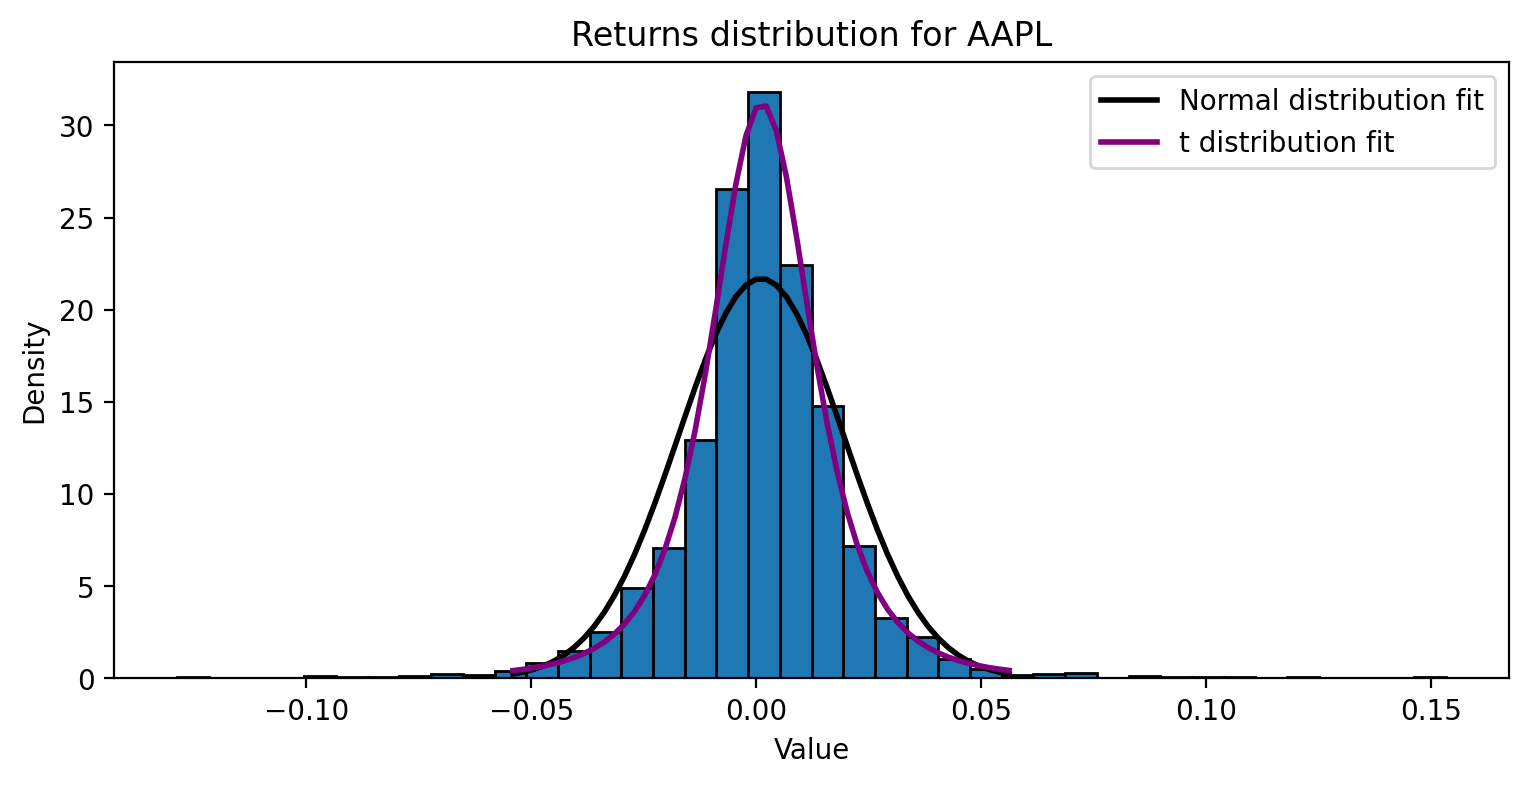

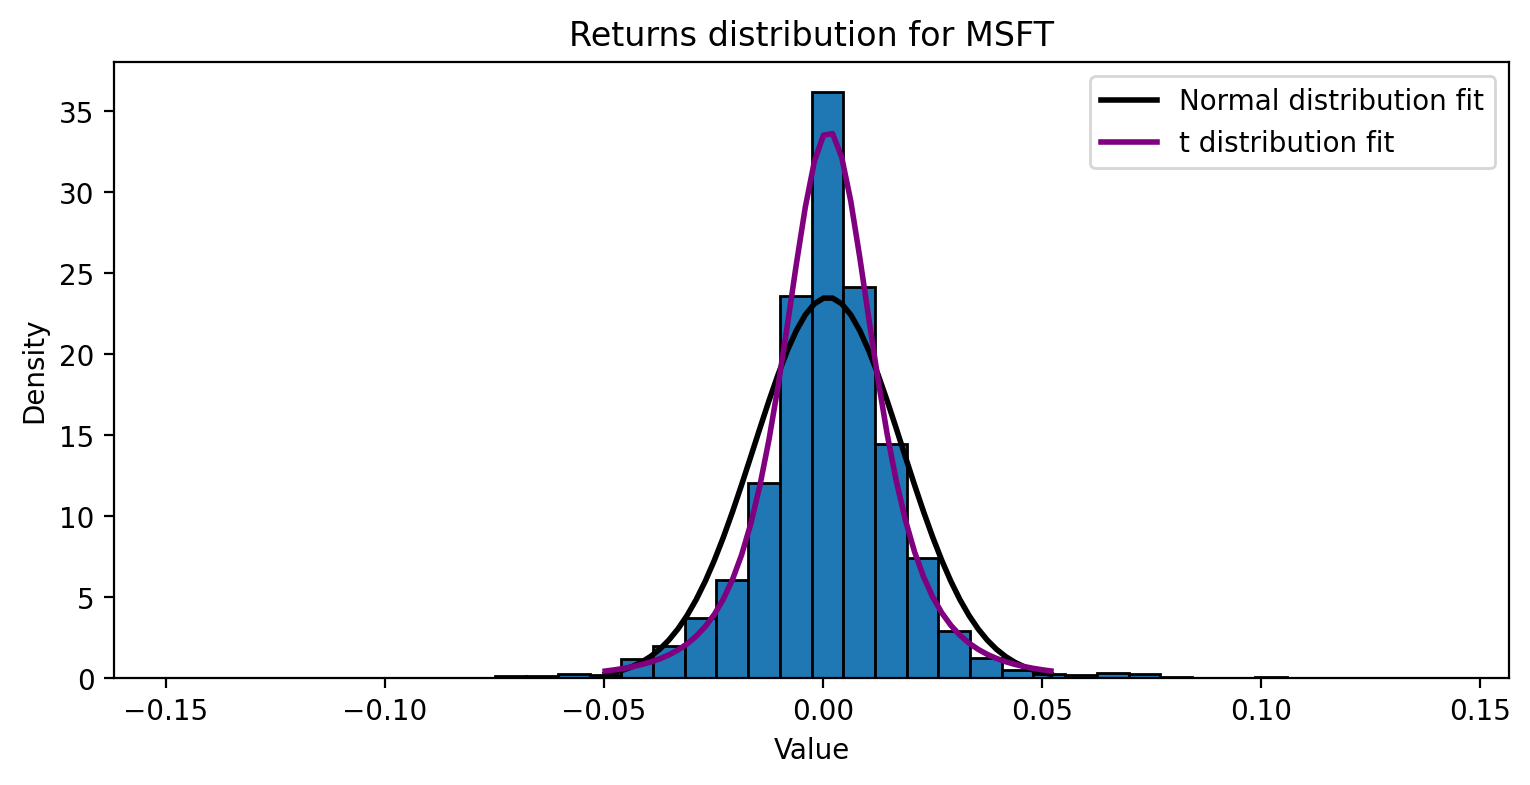

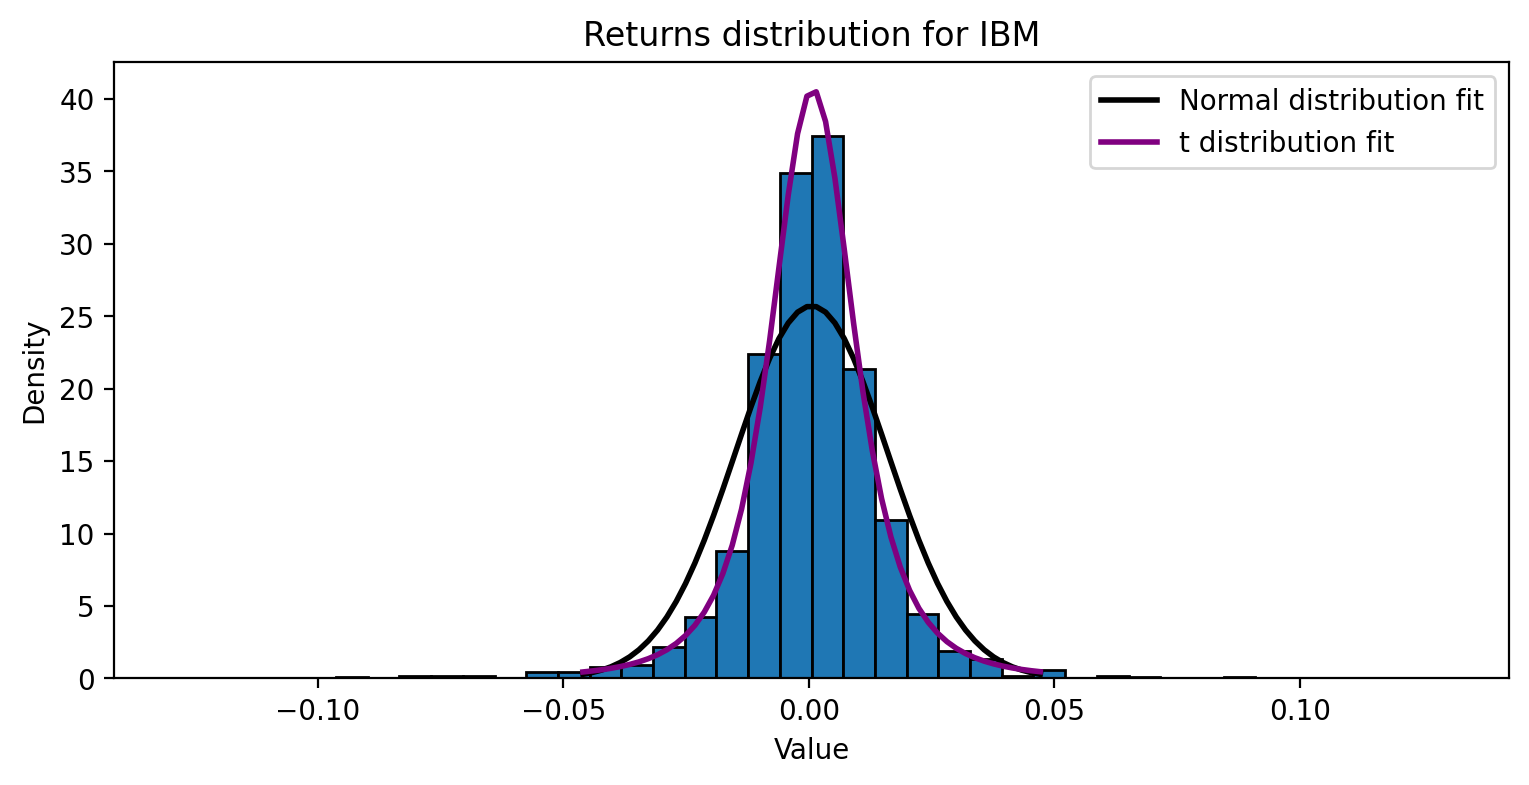

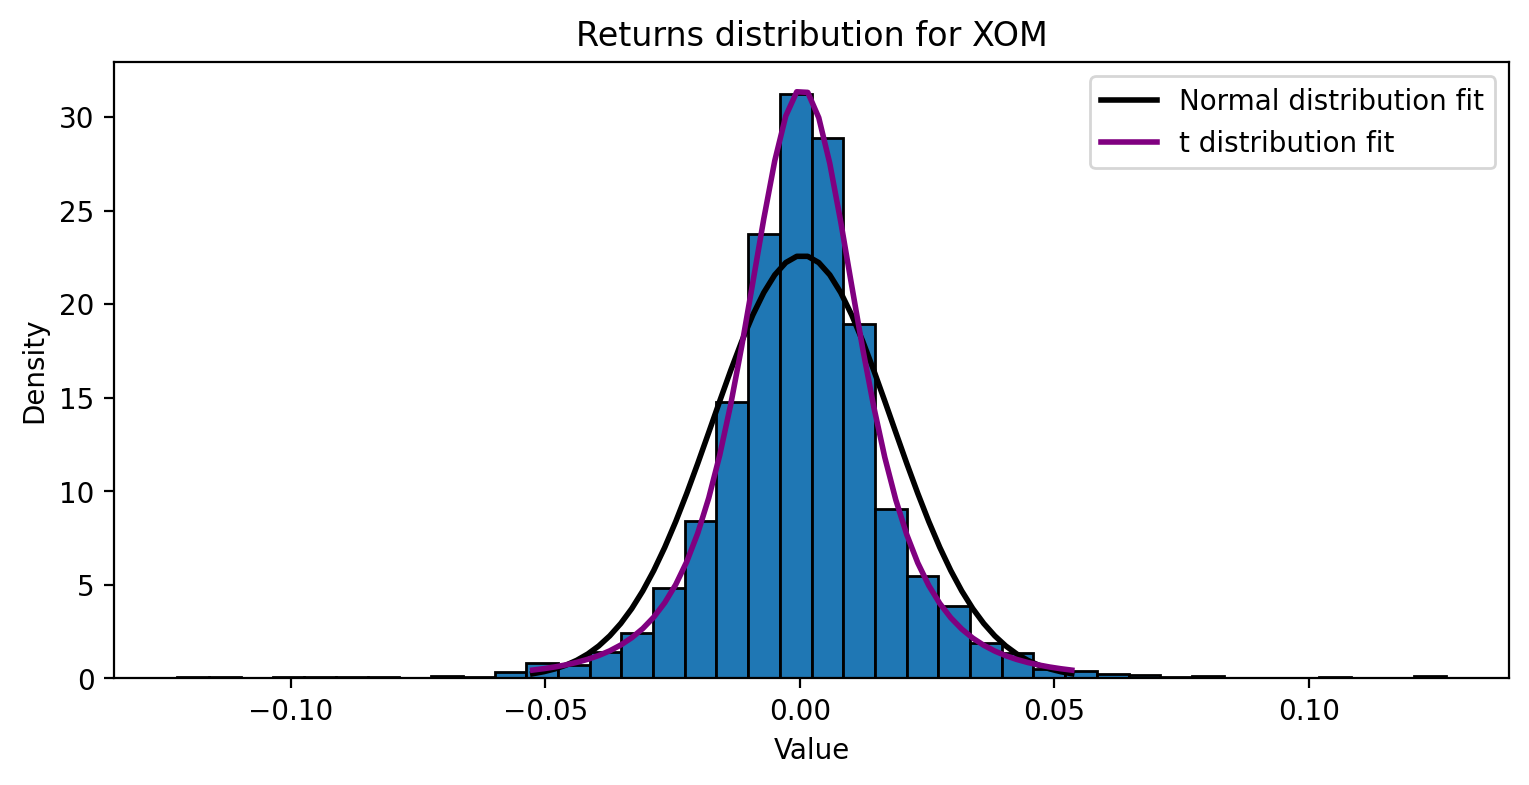

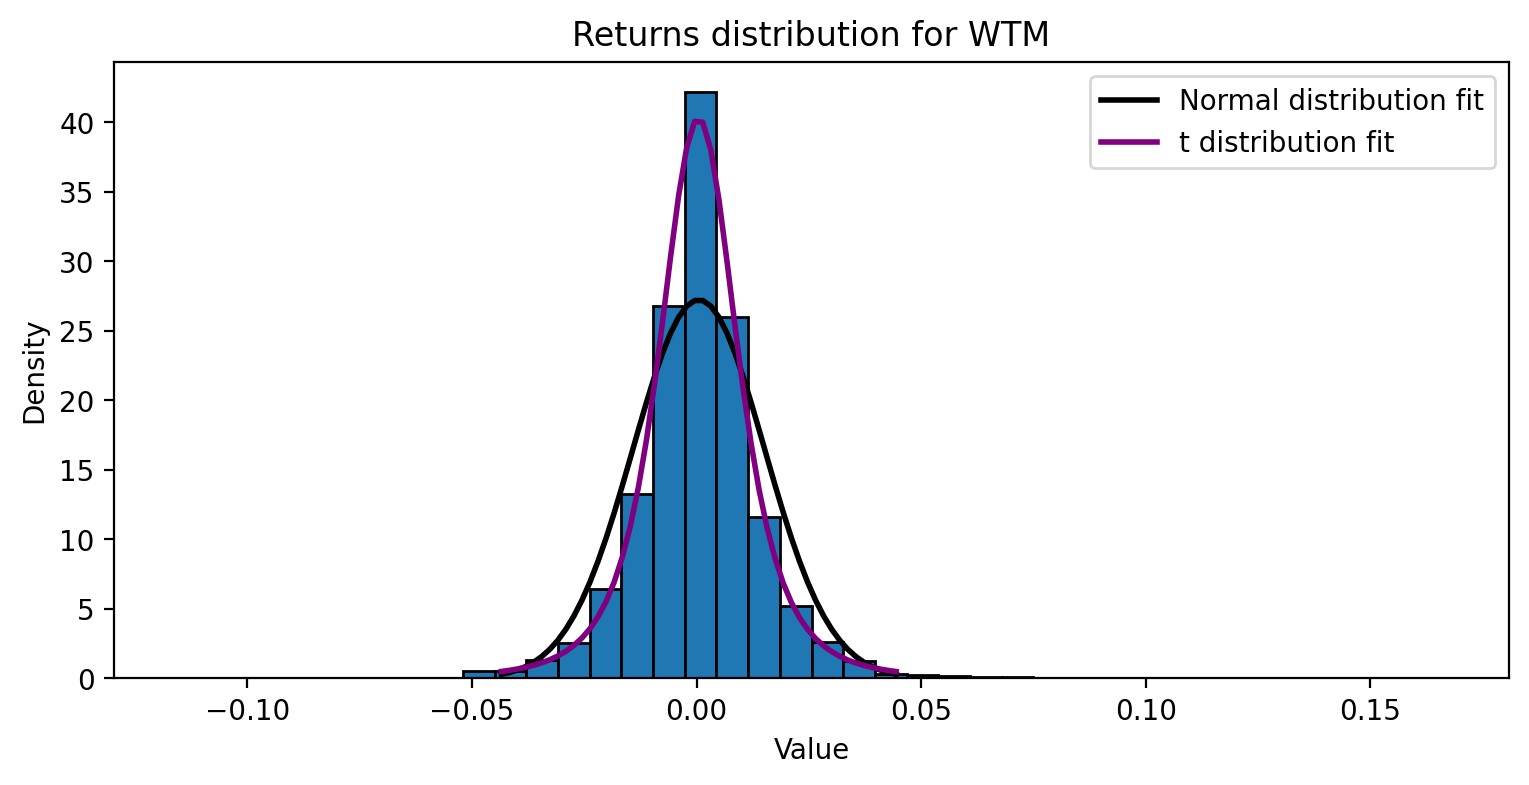

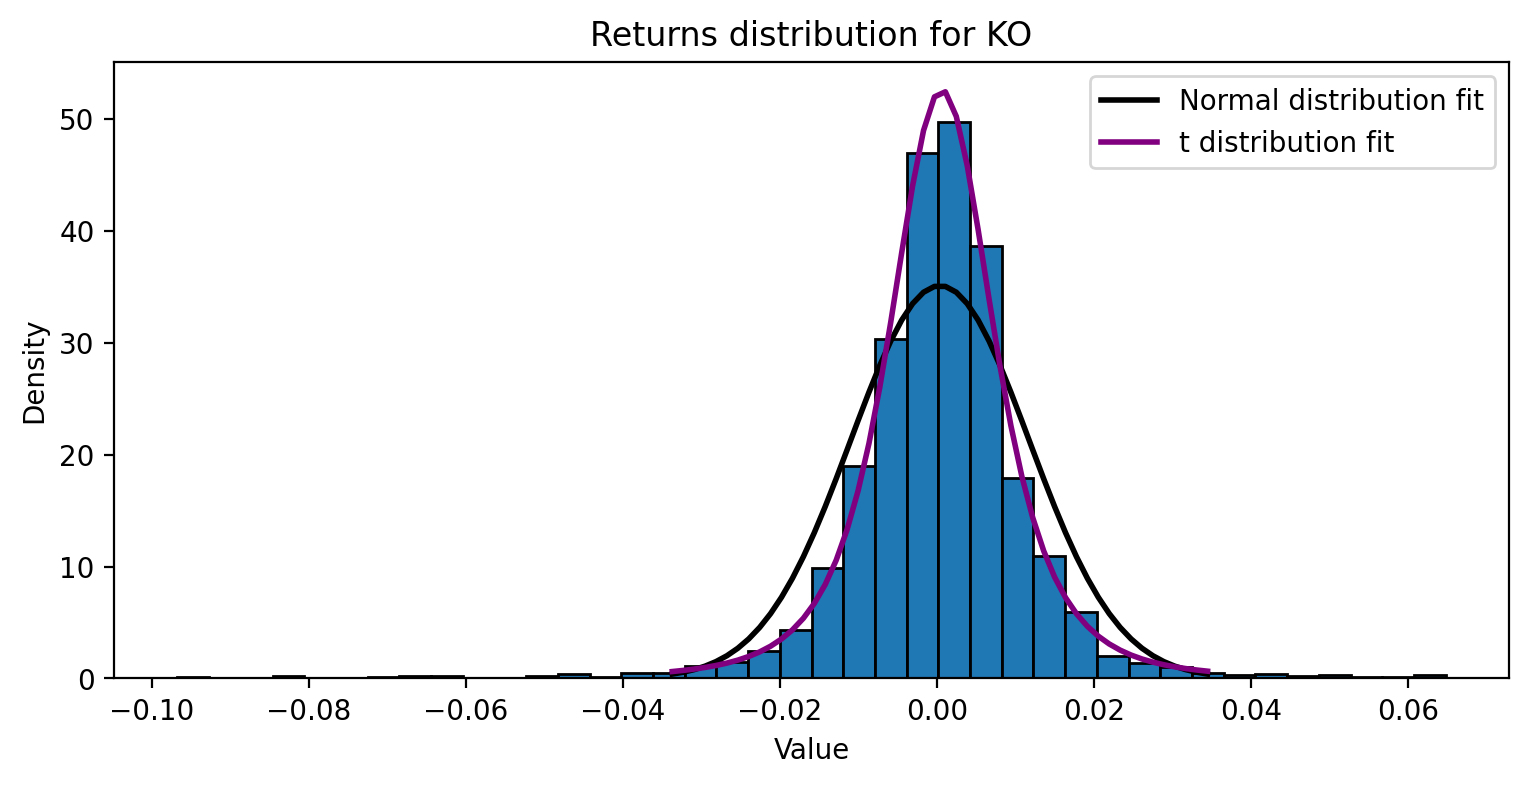

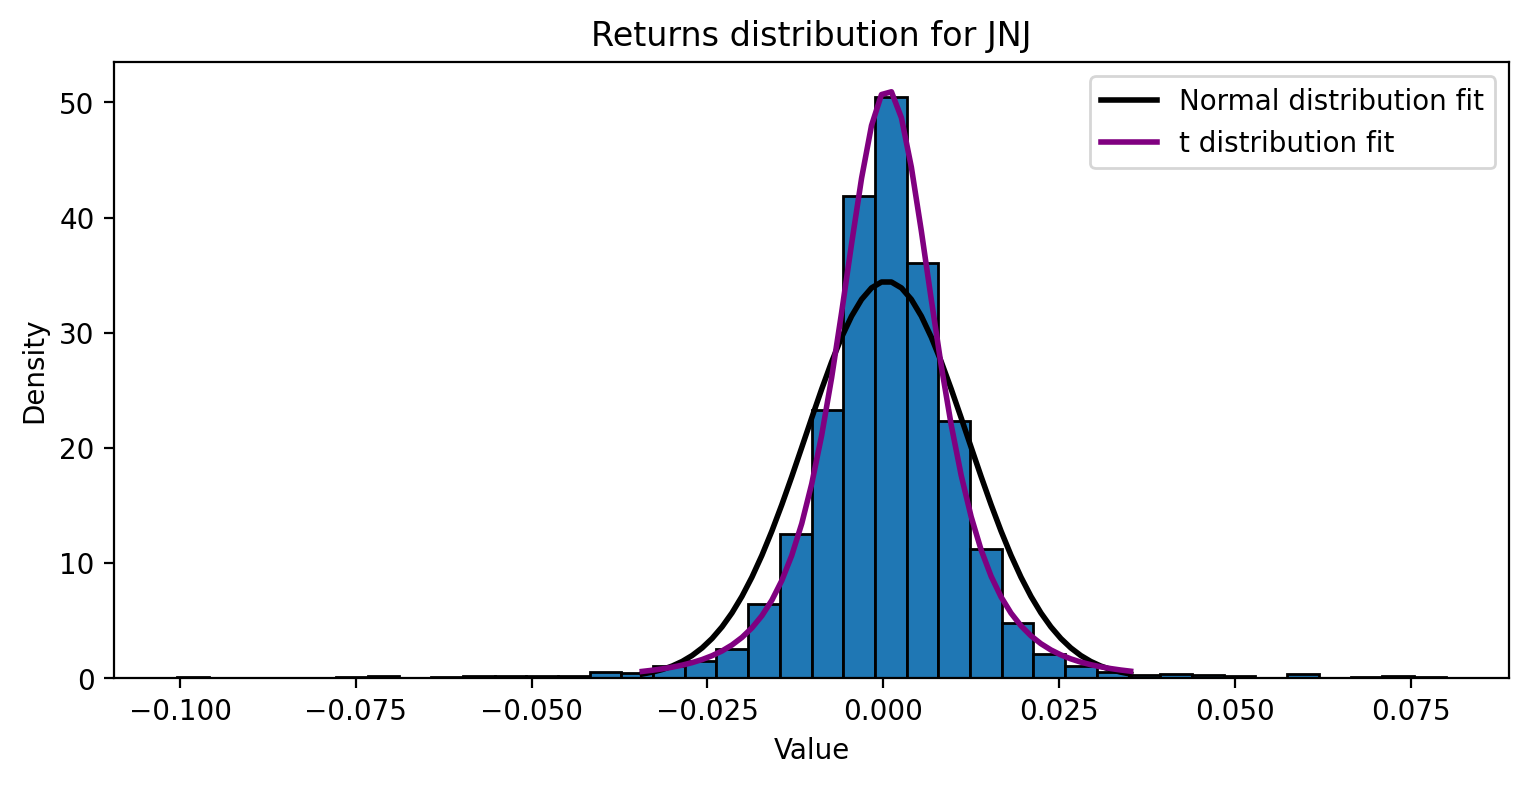

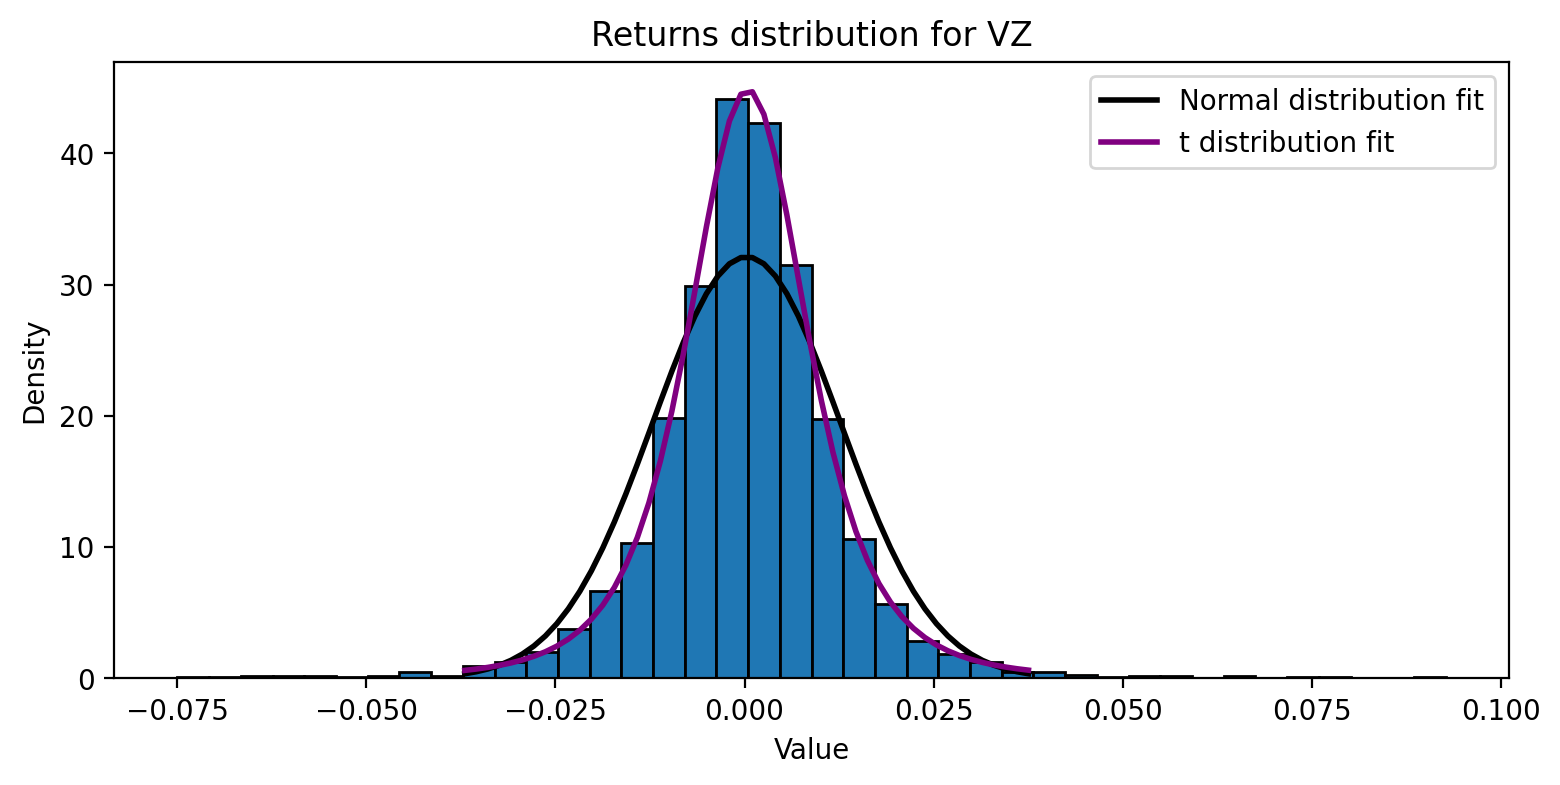

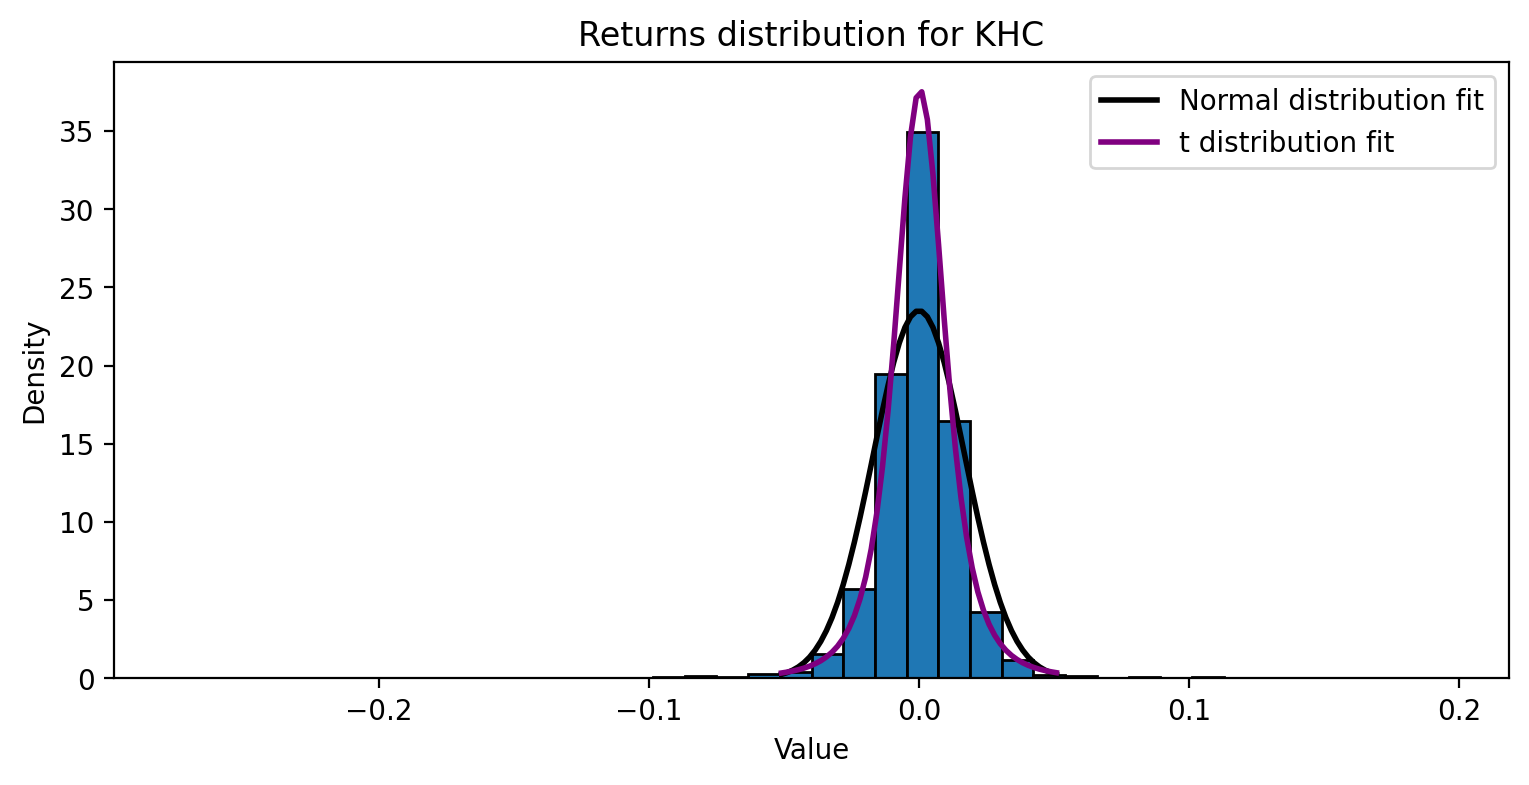

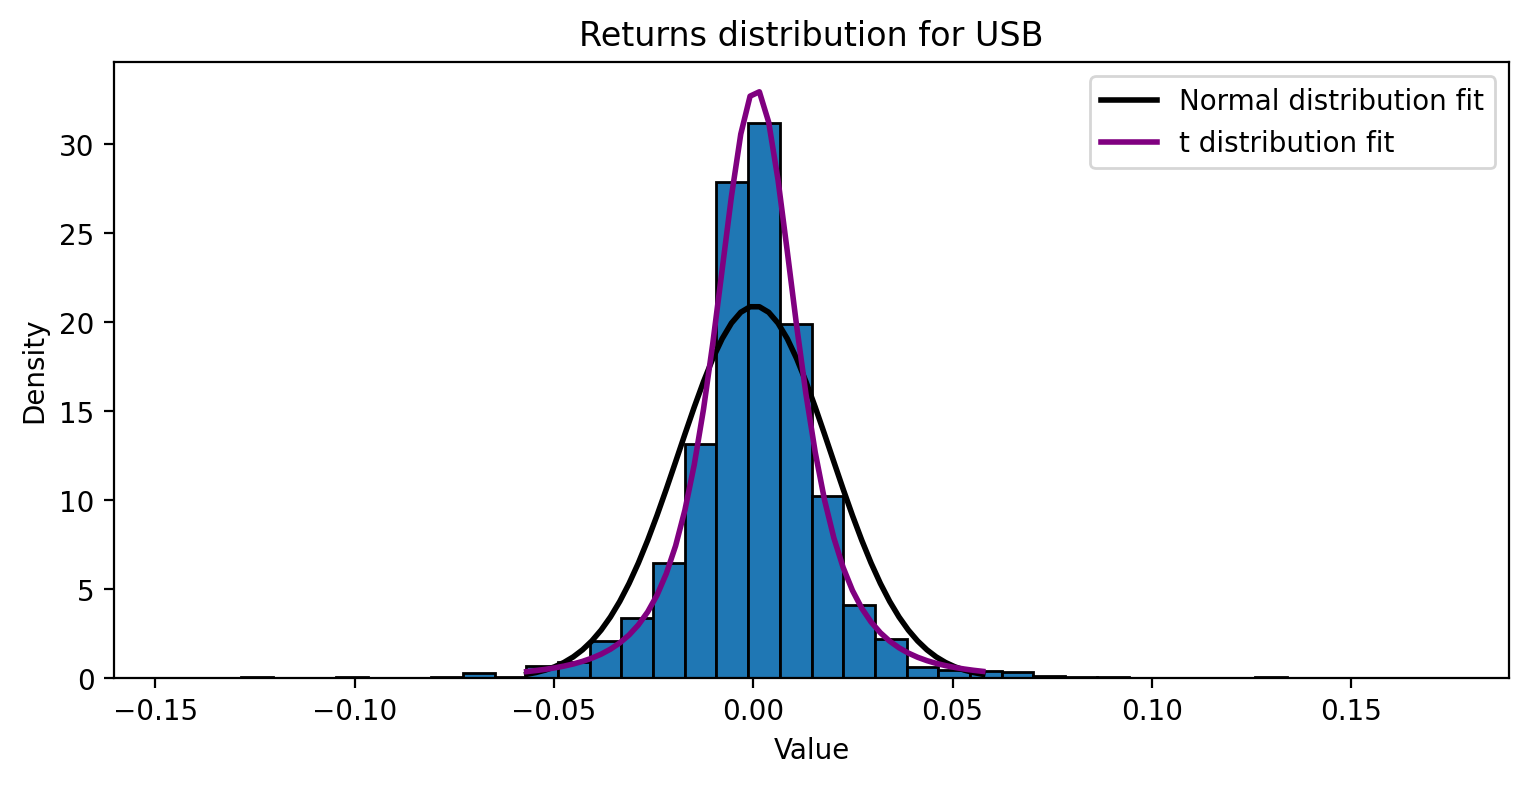

In [53]:
generate_histograms(returns_close_10y_1d, statistics)

# Run KS test to compare the CDFs 
# QQPlot

In [54]:
def generate_histograms_with_residuals(data: pd.DataFrame, num_points=100):
    for ticker in data.columns:
        ticker_data = data[ticker].dropna()
        
        # --- Create a figure with two subplots, stacked vertically ---
        # sharex=True links the x-axis of both plots for easier comparison
        fig, ax = plt.subplots(
            2, 1, 
            figsize=(10, 8), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

        # === TOP PLOT: Histogram and PDF Fits ===
        
        # 1. Get the histogram data (bar heights and bin edges)
        # We need these values to calculate the residuals later
        counts, bin_edges, _ = ax[0].hist(
            ticker_data, 
            bins=50, 
            density=True, 
            edgecolor='black', 
            alpha=0.6, 
            label='Daily Returns'
        )
        
        # Calculate the center of each histogram bin for plotting
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # 2. Fit and Plot the NORMAL Distribution
        mean, std_dev = norm.fit(ticker_data)
        normal_pdf = norm.pdf(bin_centers, mean, std_dev)
        ax[0].plot(bin_centers, normal_pdf, 'orange', linewidth=2, label='Normal Distribution Fit')

        # 3. Fit and Plot the STUDENT'S T-DISTRIBUTION
        df, loc, scale = t.fit(ticker_data)
        t_pdf = t.pdf(bin_centers, df, loc, scale)
        ax[0].plot(bin_centers, t_pdf, 'r--', linewidth=2, label="Student's t-Distribution Fit")

        ax[0].set_title(f'Distribution and Residuals for {ticker}')
        ax[0].set_ylabel("Probability Density")
        ax[0].legend()
        
        # === BOTTOM PLOT: Residuals ===

        # 4. Calculate the residuals
        normal_residuals = counts - normal_pdf
        t_residuals = counts - t_pdf

        # 5. Plot the residuals as bars
        bar_width = bin_edges[1] - bin_edges[0]
        ax[1].bar(bin_centers, normal_residuals, width=bar_width, alpha=0.6, label='Normal Fit Residuals')
        ax[1].bar(bin_centers, t_residuals, width=bar_width, alpha=0.6, label="Student's t Residuals")
        
        # Add a horizontal line at zero for reference
        ax[1].axhline(0, color='black', linestyle='--')

        ax[1].set_xlabel("Daily Returns")
        ax[1].set_ylabel("Residual (Actual - Fit)")
        ax[1].legend()

        plt.tight_layout() # Adjusts plot to prevent labels from overlapping
        plt.show()

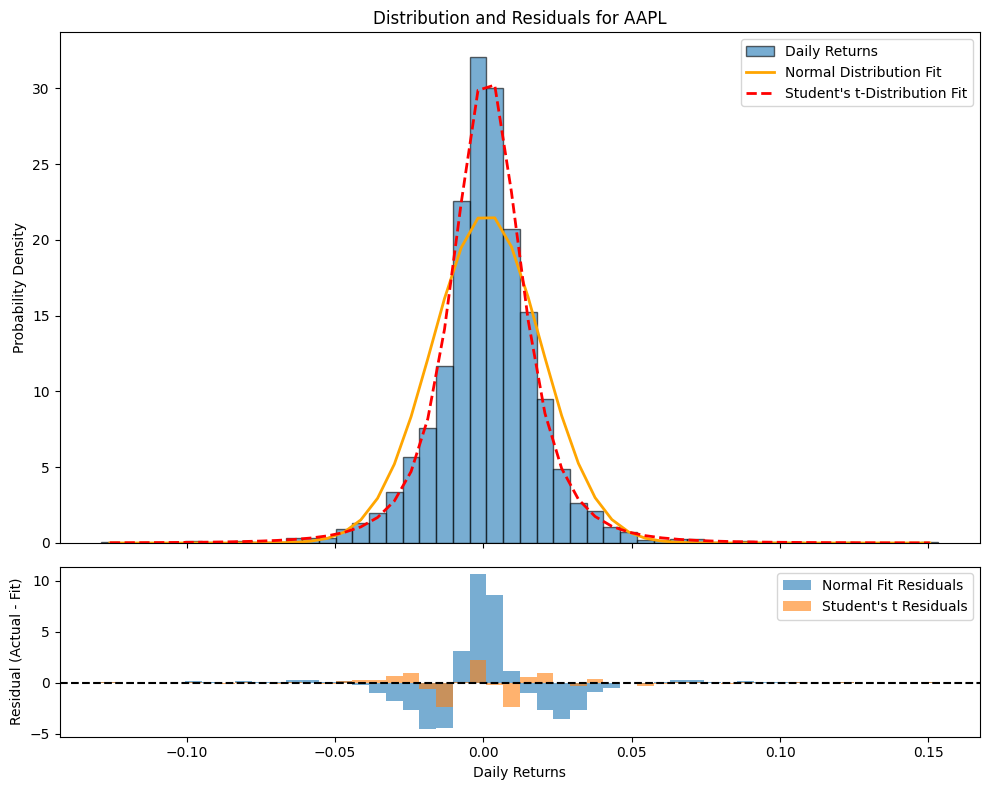

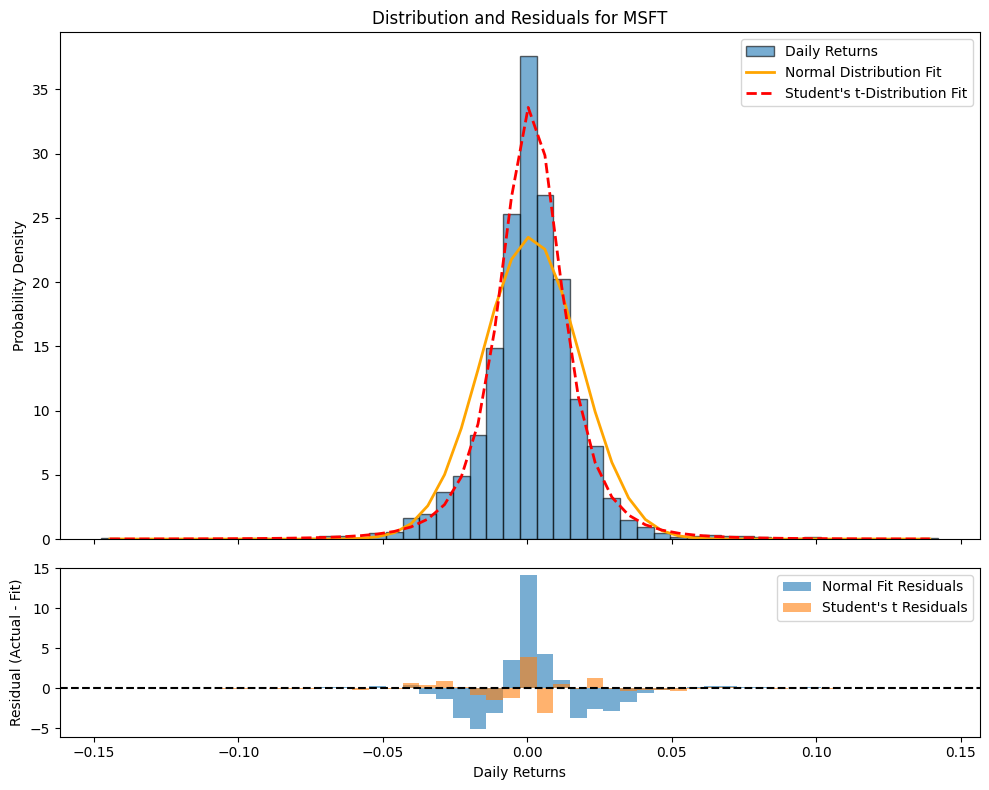

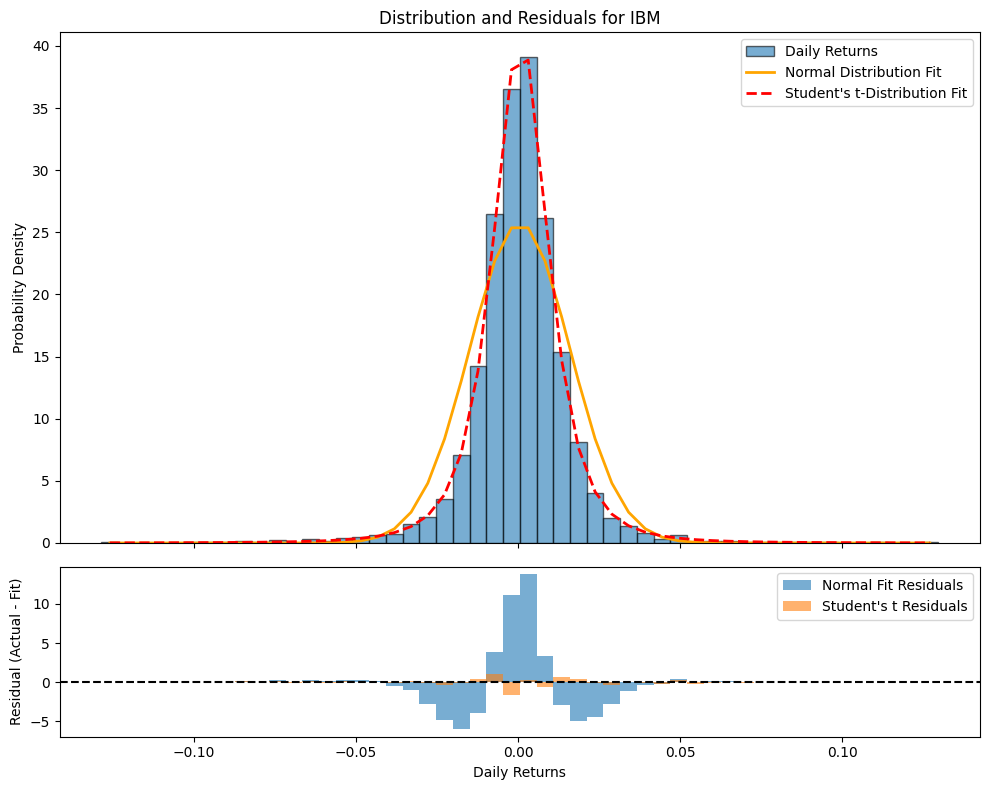

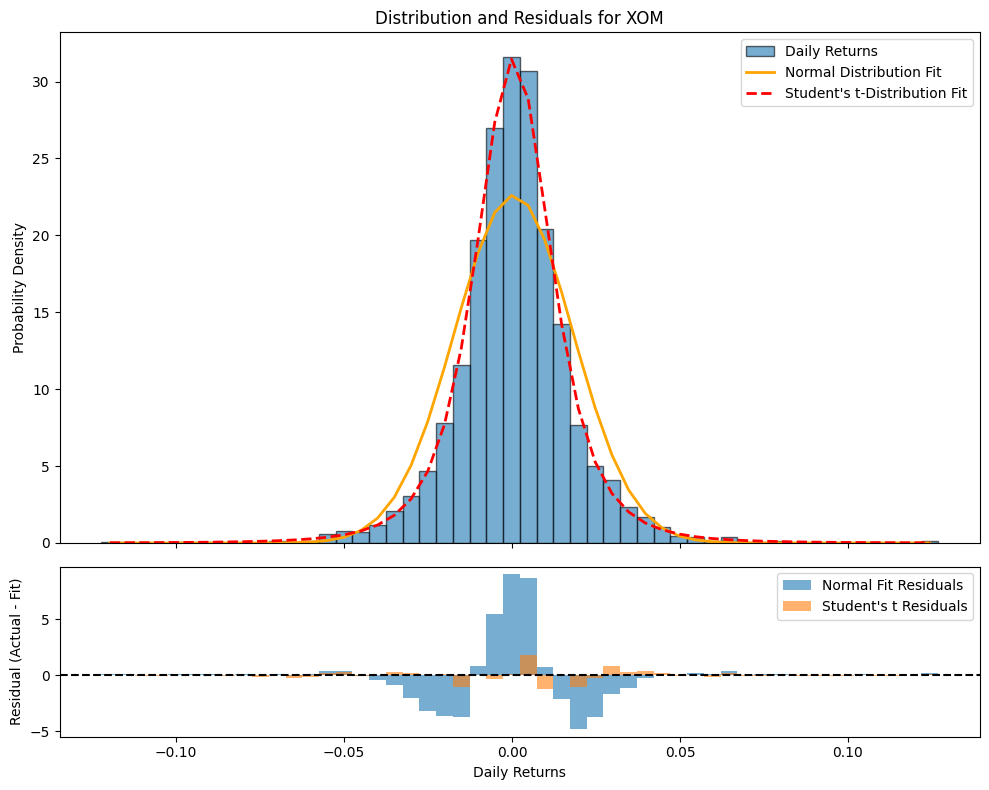

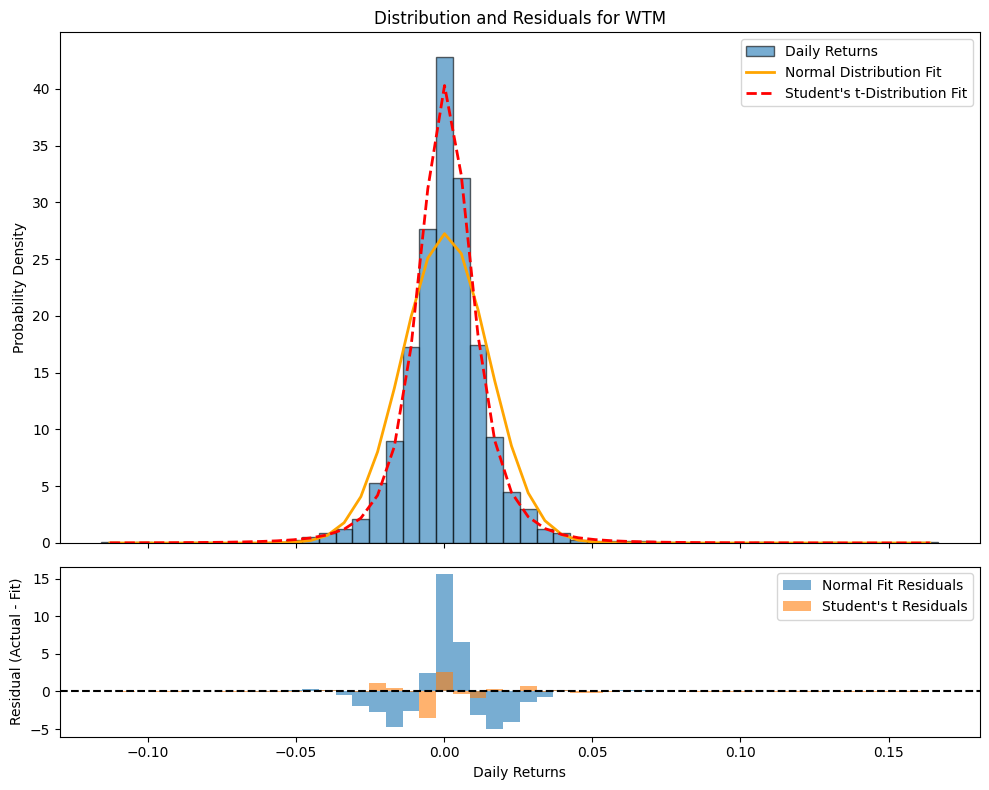

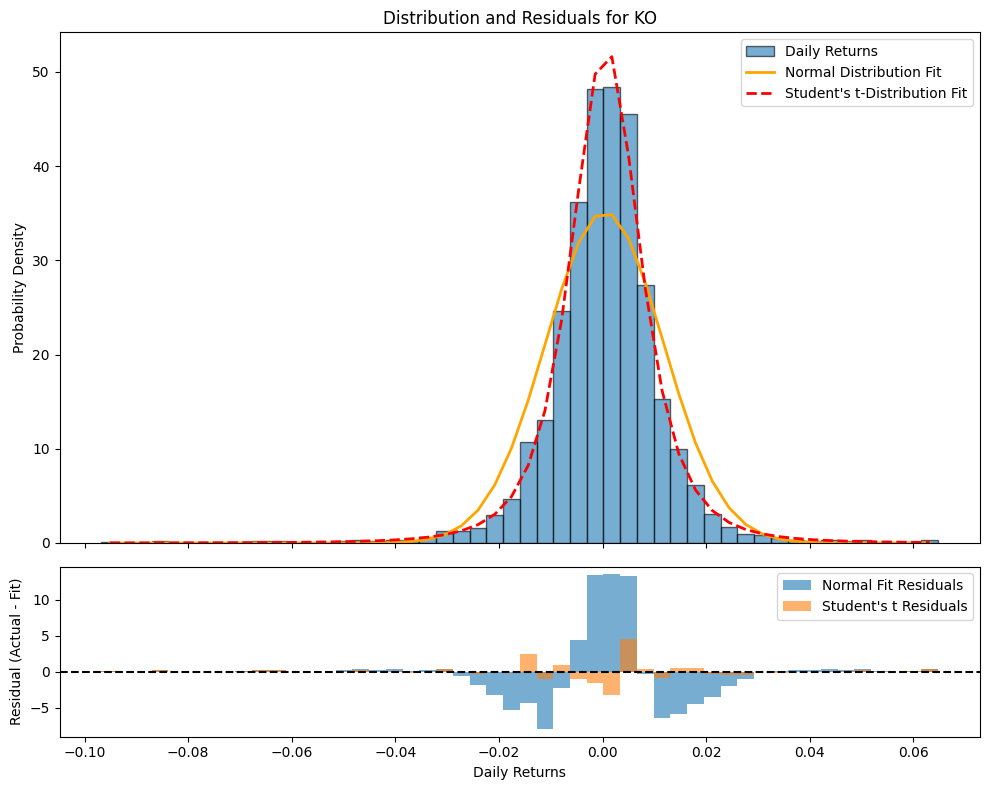

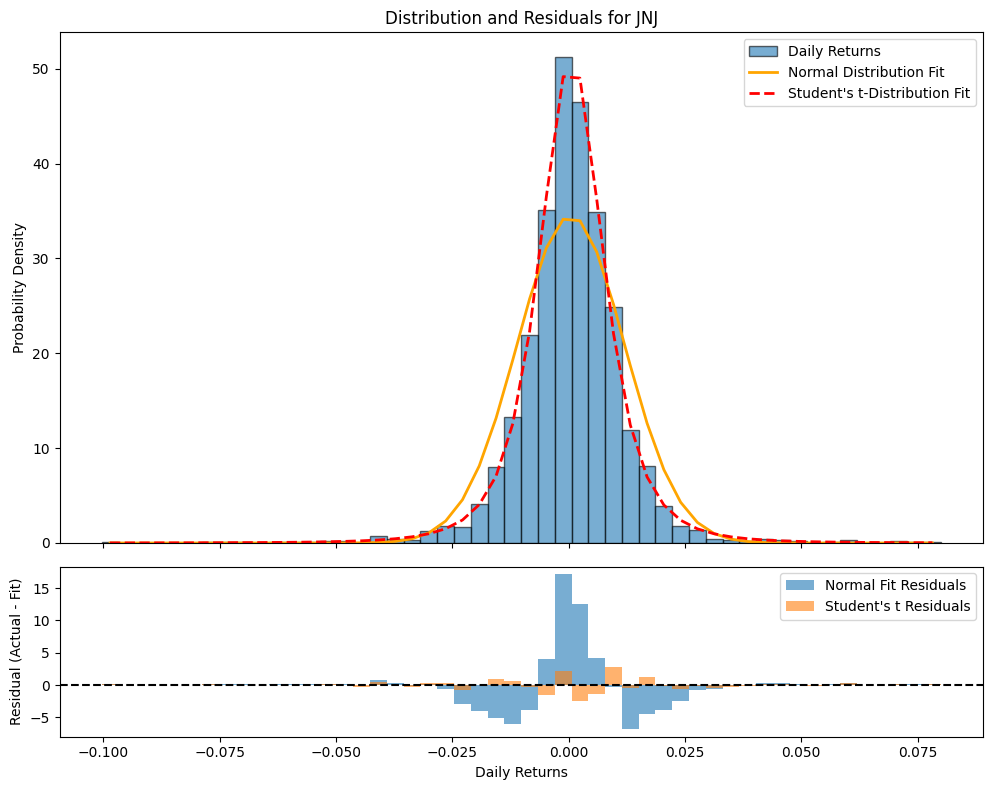

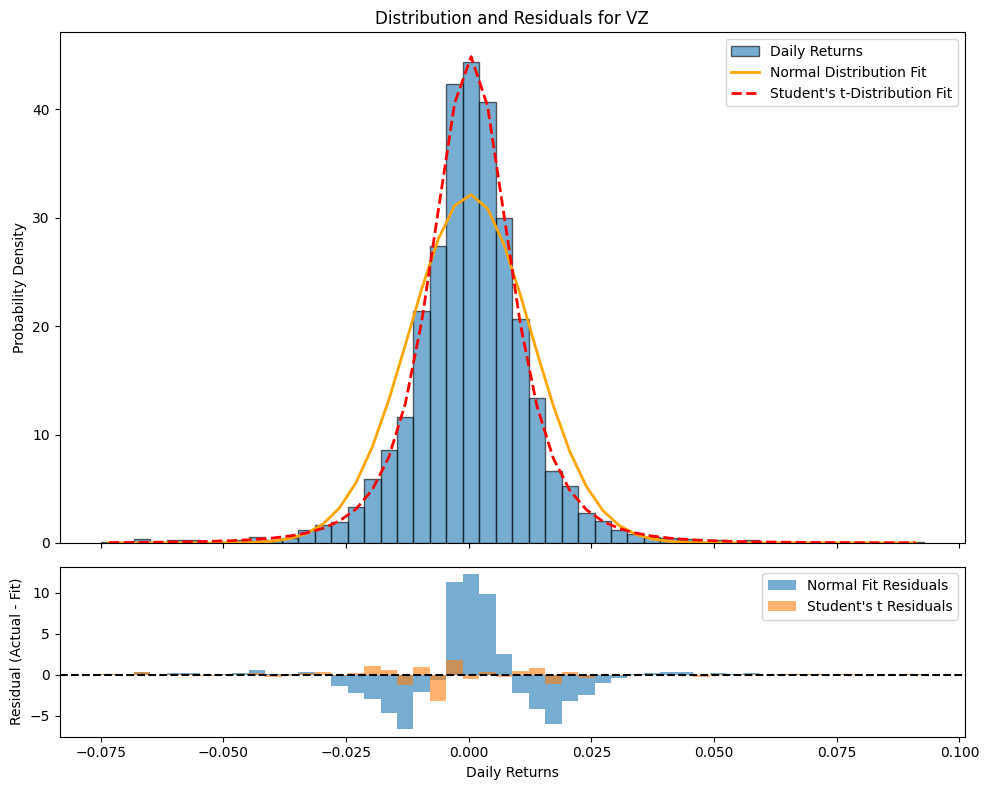

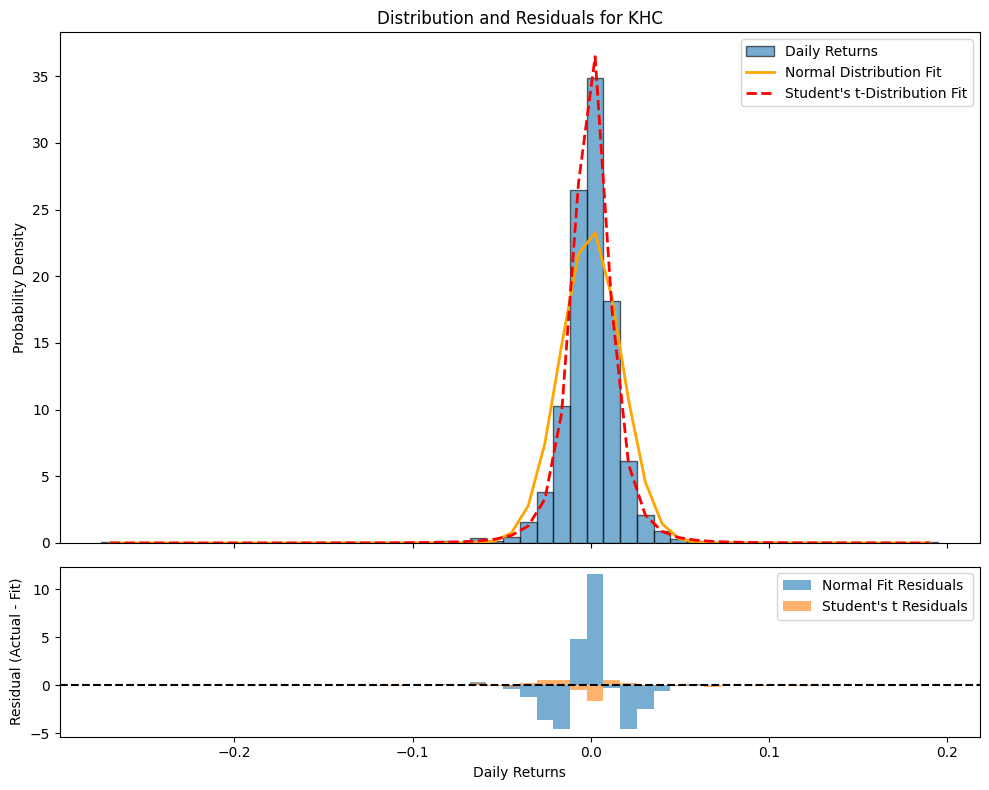

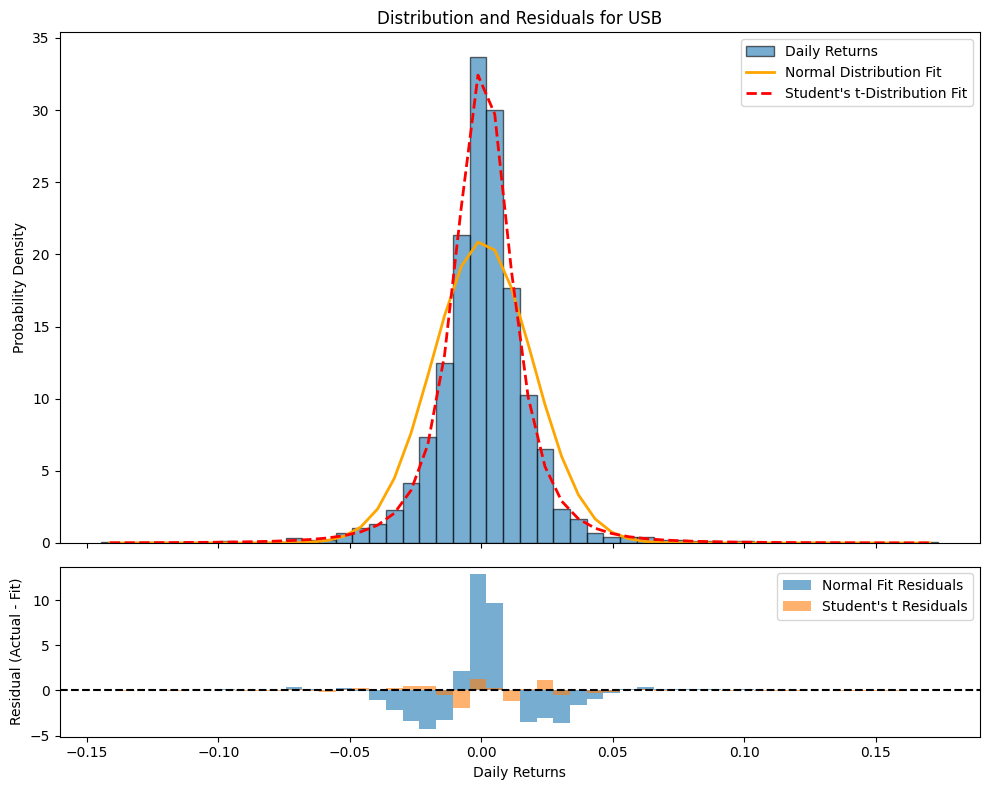

In [56]:
generate_histograms_with_residuals(returns_close_10y_1d)

In [32]:
# Define event windows (adjust as you want)
event_windows = {
    "COVID_crash": ("2020-02-15", "2020-04-30"),
    "Elections_OctNov2024": ("2024-10-01", "2024-11-30"),
    "Tariffs_April2025": ("2025-04-01", "2025-04-30"),
    "Pre_2018": ("2016-01-01", "2017-12-31"),
    "Post_2022": ("2022-01-01", "2023-12-31"),
}

# Validate: convert to datetimes
event_windows_dt = {k: (pd.to_datetime(v[0]), pd.to_datetime(v[1])) for k,v in event_windows.items()}
event_windows_dt

{'COVID_crash': (Timestamp('2020-02-15 00:00:00'),
  Timestamp('2020-04-30 00:00:00')),
 'Elections_OctNov2024': (Timestamp('2024-10-01 00:00:00'),
  Timestamp('2024-11-30 00:00:00')),
 'Tariffs_April2025': (Timestamp('2025-04-01 00:00:00'),
  Timestamp('2025-04-30 00:00:00')),
 'Pre_2018': (Timestamp('2016-01-01 00:00:00'),
  Timestamp('2017-12-31 00:00:00')),
 'Post_2022': (Timestamp('2022-01-01 00:00:00'),
  Timestamp('2023-12-31 00:00:00'))}

In [37]:
data_10y_1d['AAPL_10y_1d_cleaned']

,Close,High,Low,Open,Volume,Return
Date,,,,,,
2015-10-05,24.895094,25.027683,24.510813,24.692841,208258800,NaN
2015-10-06,25.014200,25.110832,24.668123,24.861387,192787200,0.004784
2015-10-07,24.895094,25.117572,24.587221,25.110830,187062400,-0.004762
2015-10-08,24.607449,24.762510,24.317552,24.762510,247918400,-0.011554
2015-10-09,25.196228,25.232183,24.605199,24.719809,211064400,0.023927
...,...,...,...,...,...,...
2025-09-29,254.429993,255.000000,253.009995,254.559998,40127700,-0.004032
2025-09-30,254.630005,255.919998,253.110001,254.860001,37704300,0.000786
2025-10-01,255.449997,258.790009,254.929993,255.039993,48713900,0.003220


In [43]:
event_windows_dt['COVID_crash'][0]

Timestamp('2020-02-15 00:00:00')

In [53]:
data_10y_1d['AAPL_10y_1d_cleaned'].loc[event_windows_dt['COVID_crash'][0]:event_windows_dt['COVID_crash'][1]]['Close']

Date
2020-02-18    77.225601
2020-02-19    78.344025
2020-02-20    77.540268
2020-02-21    75.785164
2020-02-24    72.185349
2020-02-25    69.740280
2020-02-26    70.846611
2020-02-27    66.215477
2020-02-28    66.176765
2020-03-02    72.337852
2020-03-03    70.040451
2020-03-04    73.289238
2020-03-05    70.911980
2020-03-06    69.970261
2020-03-09    64.436172
2020-03-10    69.076935
2020-03-11    66.677887
2020-03-12    60.093121
2020-03-13    67.292778
2020-03-16    58.635773
2020-03-17    61.213985
2020-03-18    59.715466
2020-03-19    59.257919
2020-03-20    55.495903
2020-03-23    54.316940
2020-03-24    59.766308
2020-03-25    59.437073
2020-03-26    62.564827
2020-03-27    59.974495
2020-03-30    61.686054
2020-03-31    61.560173
2020-04-01    58.321049
2020-04-02    59.294239
2020-04-03    58.442097
2020-04-06    63.540440
2020-04-07    62.804474
2020-04-08    64.411964
2020-04-09    64.876740
2020-04-13    66.150124
2020-04-14    69.490921
2020-04-15    68.856651
2020-04-16 

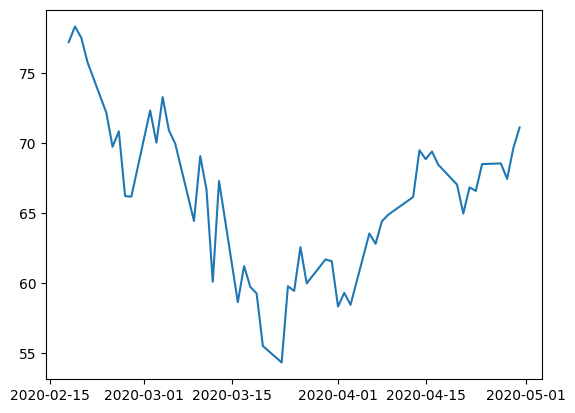

In [54]:
plt.plot(data_10y_1d['AAPL_10y_1d_cleaned'].loc[event_windows_dt['COVID_crash'][0]:event_windows_dt['COVID_crash'][1]]['Close'])

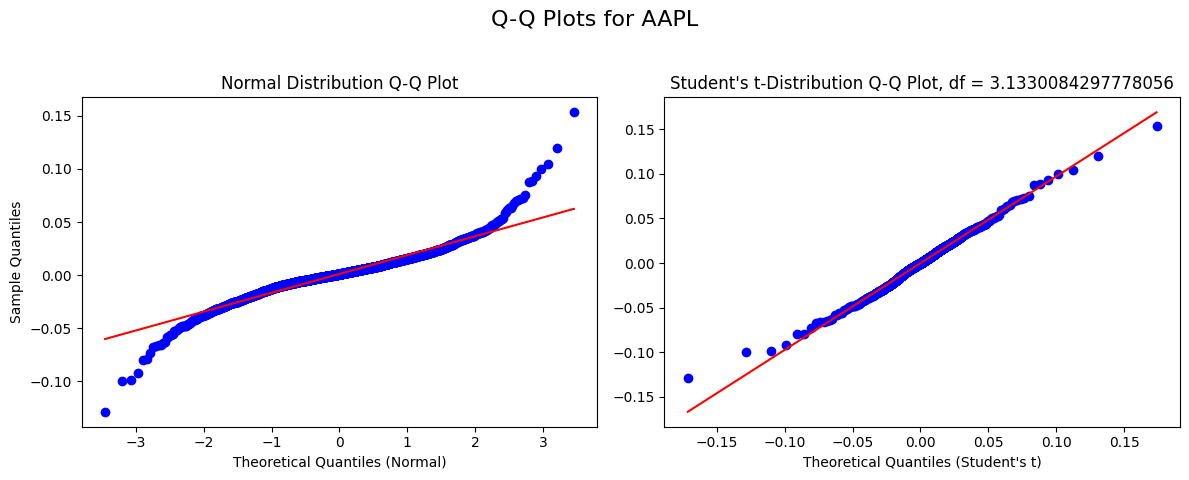

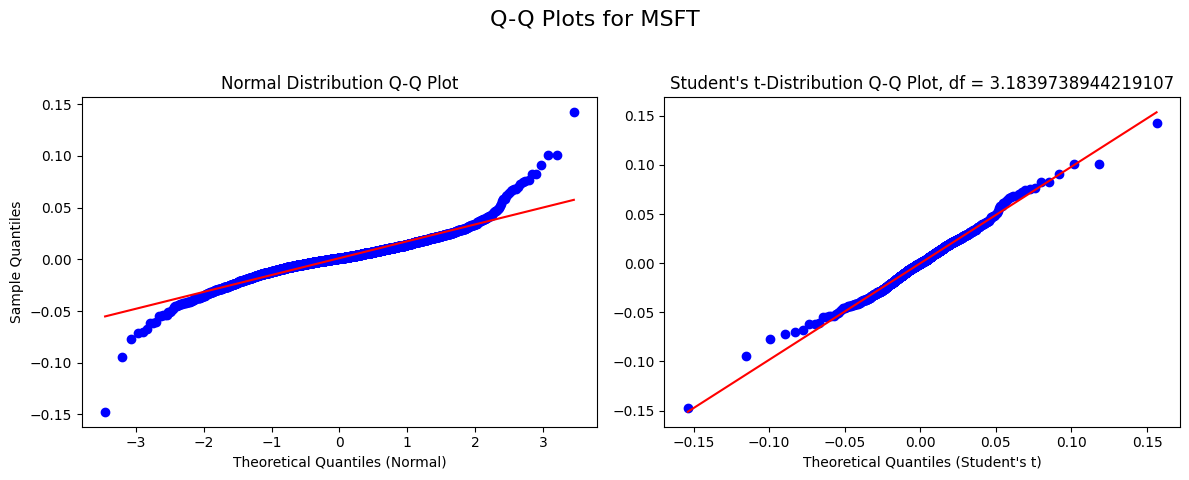

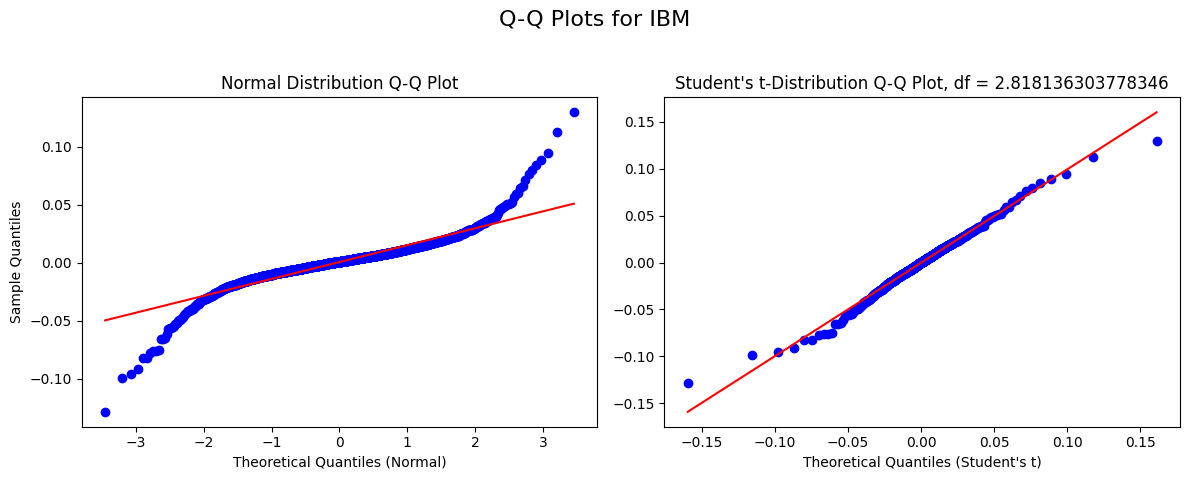

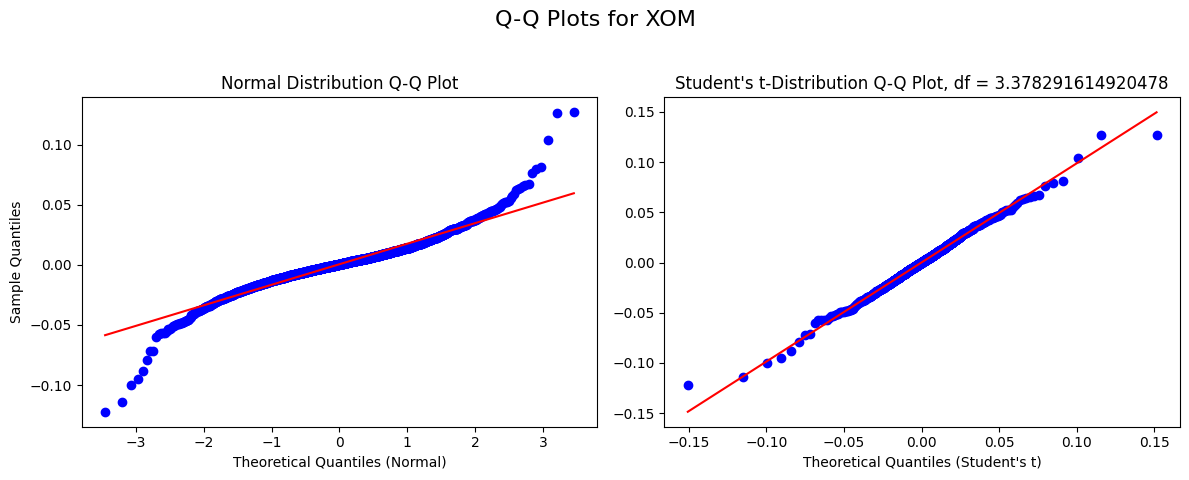

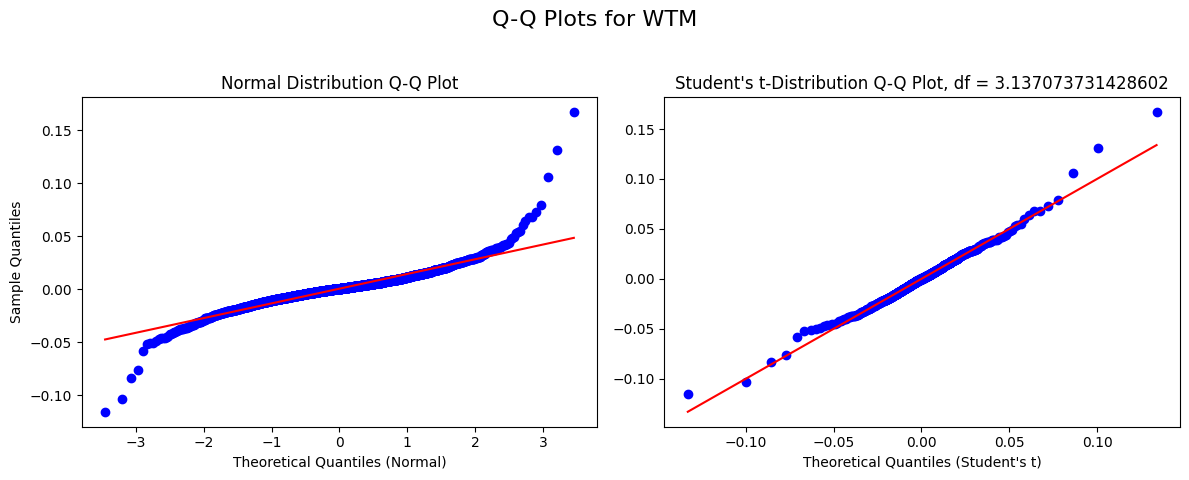

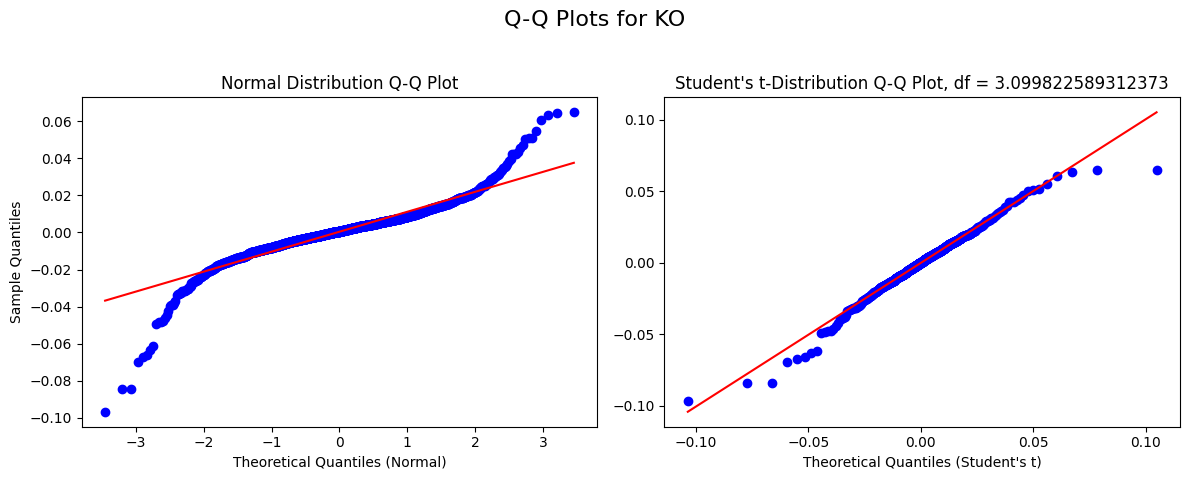

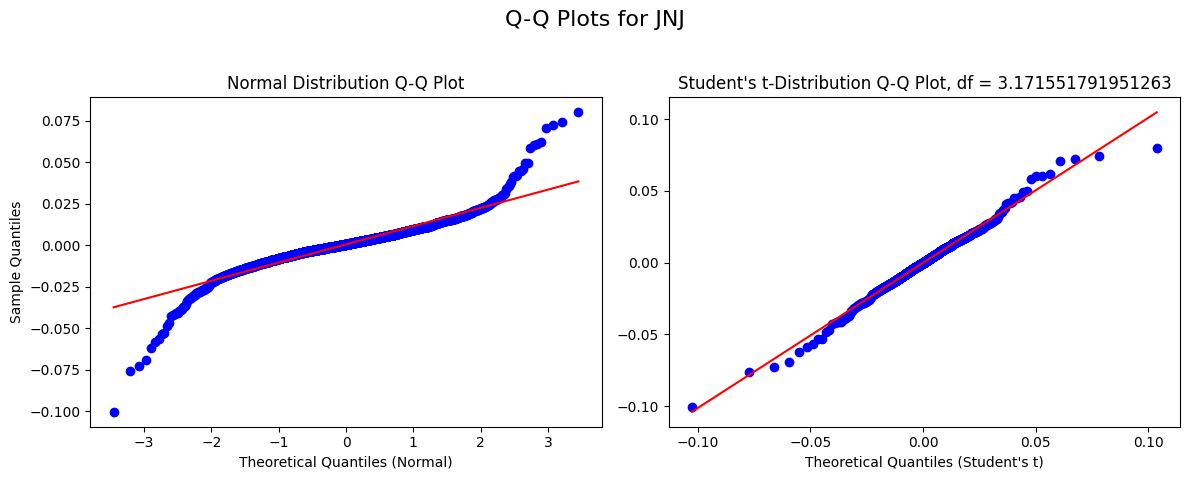

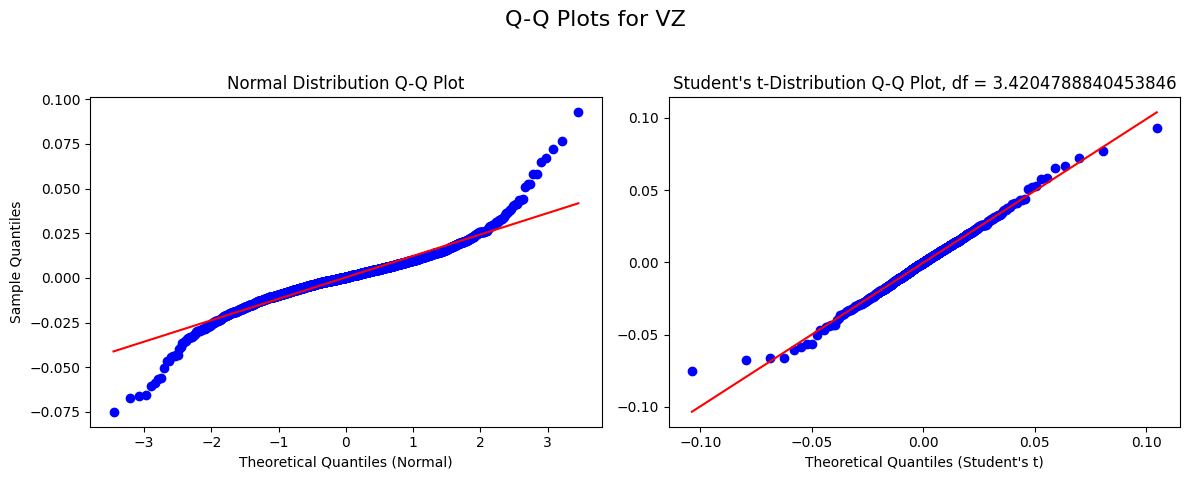

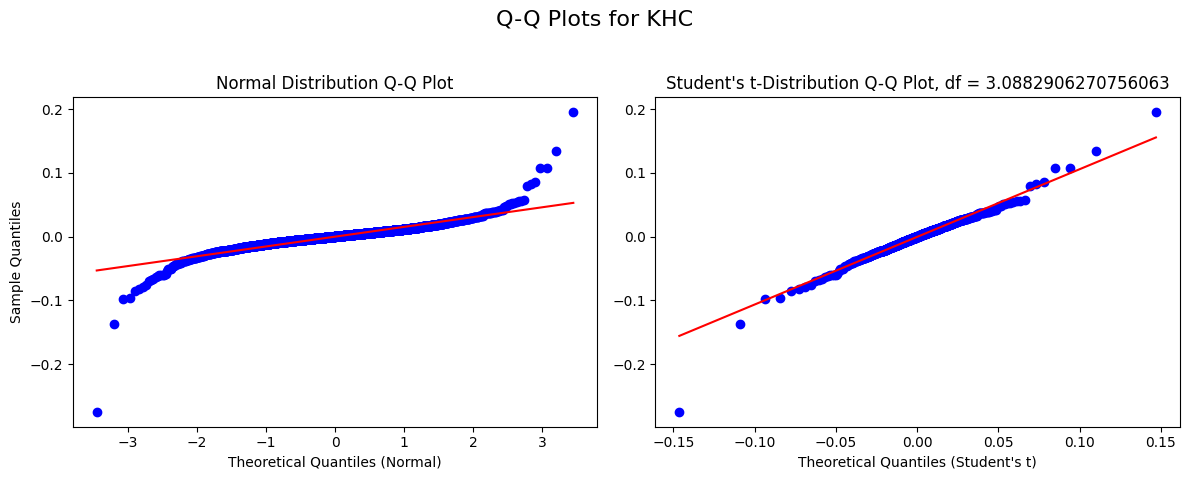

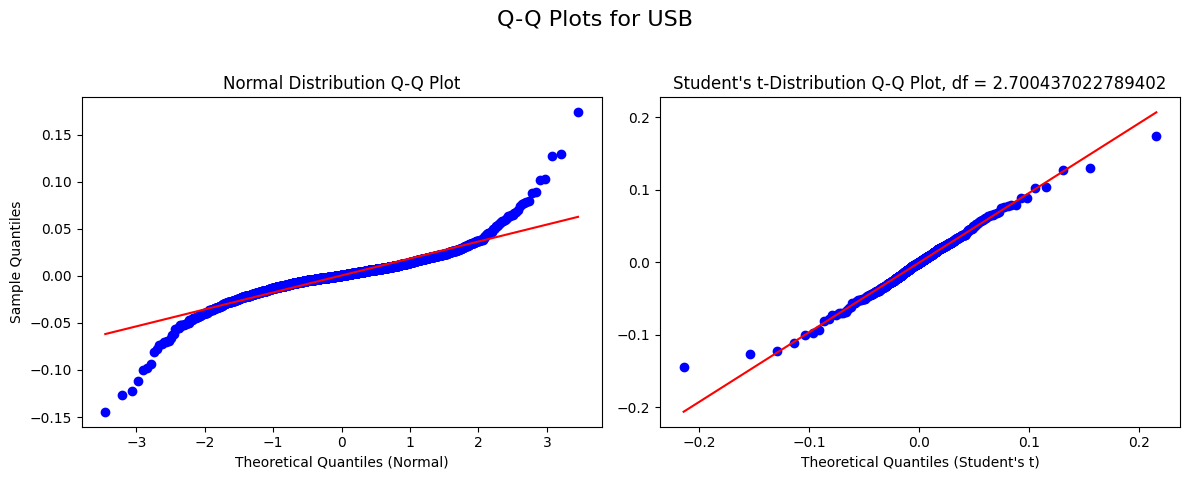

In [12]:
generate_qq_plots(returns_close_10y_1d)

How close does it looks like a t dist? Try to compare with other distributions

How significant it is? with respect to the t

1. Capture cash dividends, see what effect that has on the daily, and then move into intraday, see how a day trader may.


Do a KS test

max(abs(CDF empirical - CDF theorical))

Minute over minute returns and chart those then check its distributions

shapes, mean, kurtosis, skewness, etc... 

Daily: subsegment in specific dates, when markets are more volatile (near crisis = volatility is higher ) march 2020, etc... historical periods.

Tariffs - April 2025
Check extreme returns in the SP500 during the last years
Elections - October / November 2024
